In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

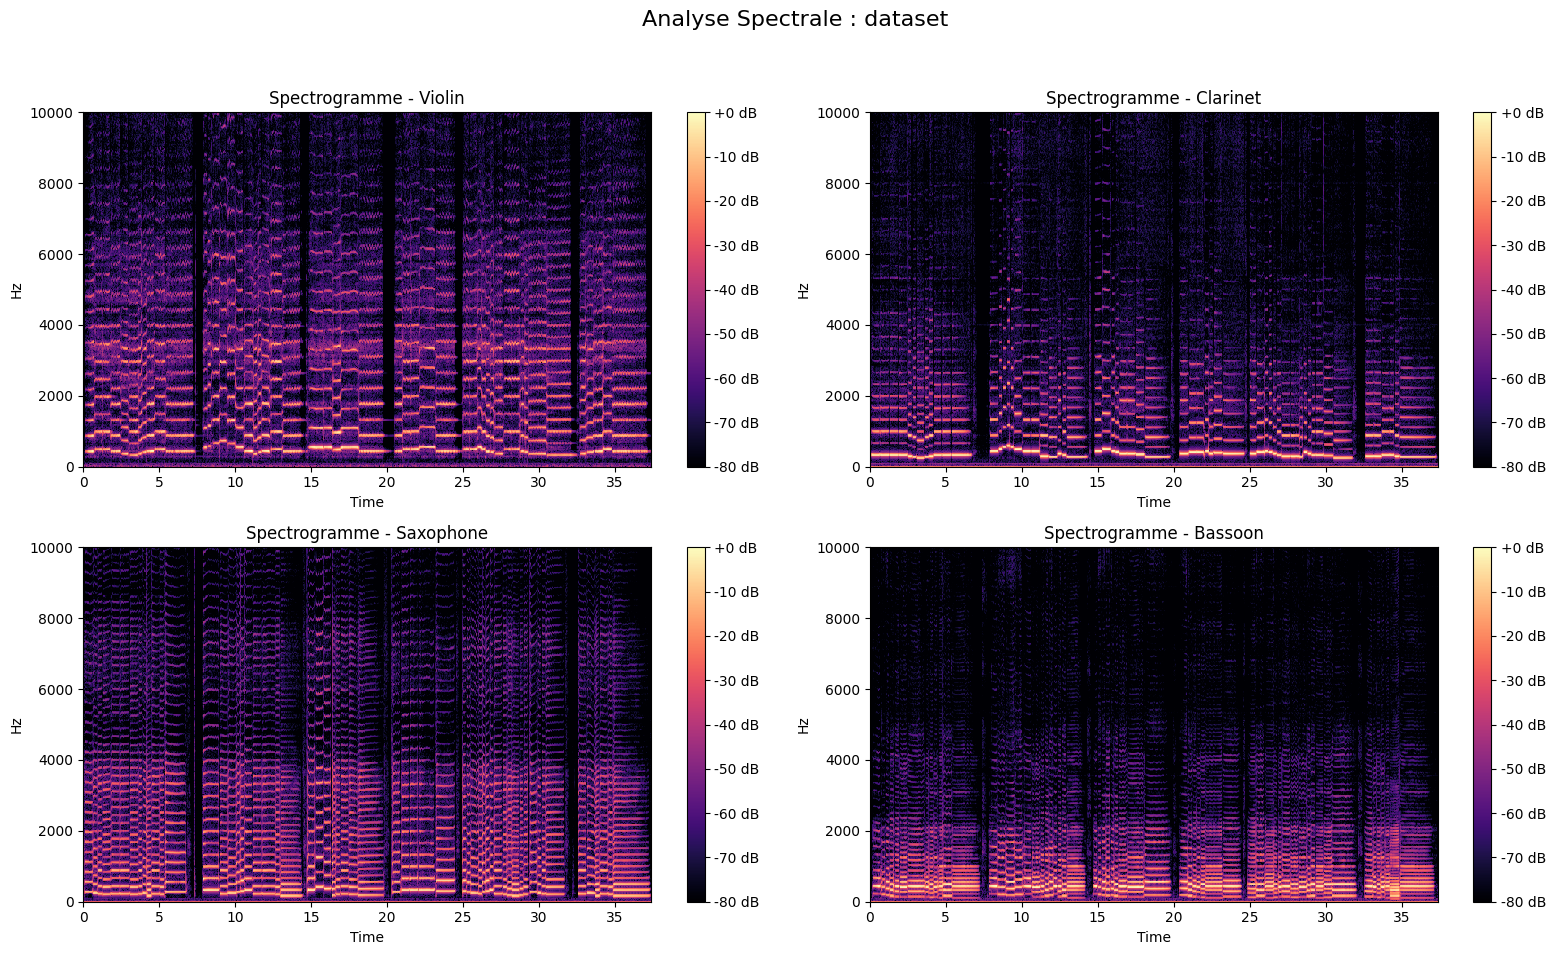

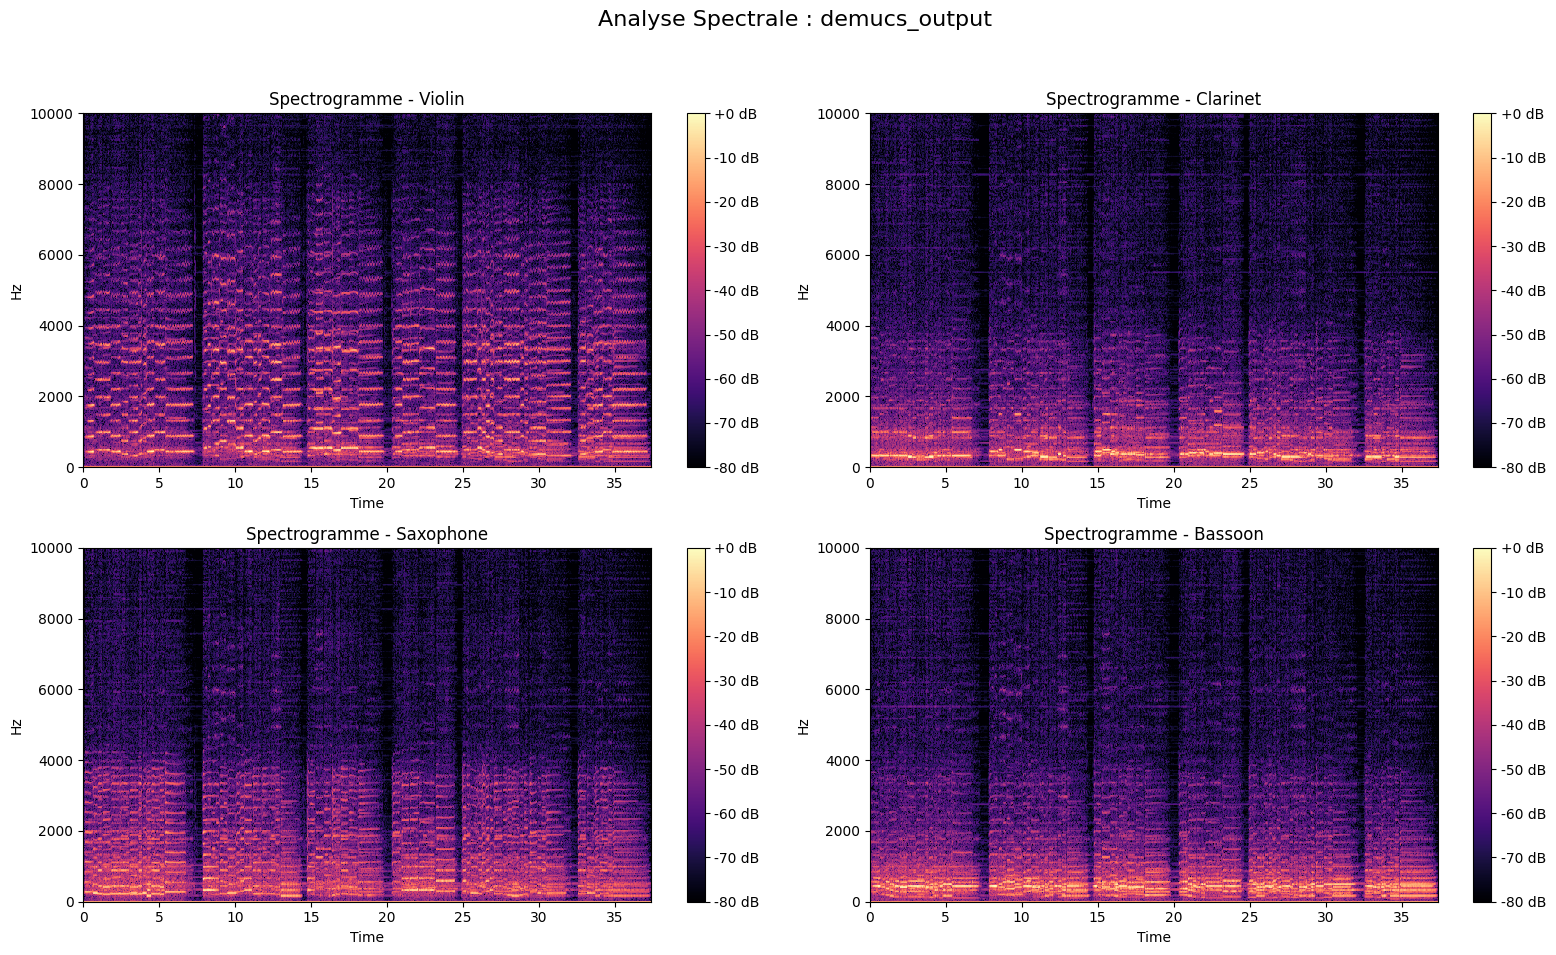

In [7]:
def plot_spectrograms(output_dir, song_name):
    # Liste des instruments
    instruments = ["violin", "clarinet", "saxophone", "bassoon"]

    plt.figure(figsize=(16, 10))
    plt.suptitle(f"Analyse Spectrale : {song_name}", fontsize=16)

    for i, inst in enumerate(instruments):
        # Construction du chemin (adapte selon ton dossier de sortie)
        file_path = Path(output_dir) / f"{inst}.wav"

        if not file_path.exists():
            print(f"Fichier introuvable : {file_path}")
            continue

        # 1. Chargement du signal
        y, sr = librosa.load(file_path, sr=None)

        # 2. Calcul de la STFT (Short-Time Fourier Transform)
        # On passe en décibels pour une meilleure visualisation
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

        # 3. Affichage
        plt.subplot(2, 2, i + 1)
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Spectrogramme - {inst.capitalize()}")
        plt.ylim(0, 10000)  # On limite à 10kHz pour mieux voir les détails musicaux

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Utilisation :
plot_spectrograms("/home/ensta/ensta-baron/Projet_IA_2526/Bach10_Clean/test/10-NunBitten", "dataset")
plot_spectrograms("/home/ensta/ensta-baron/Projet_IA_2526/src/fine-tuning_Bach/output/augmented", "demucs_output")

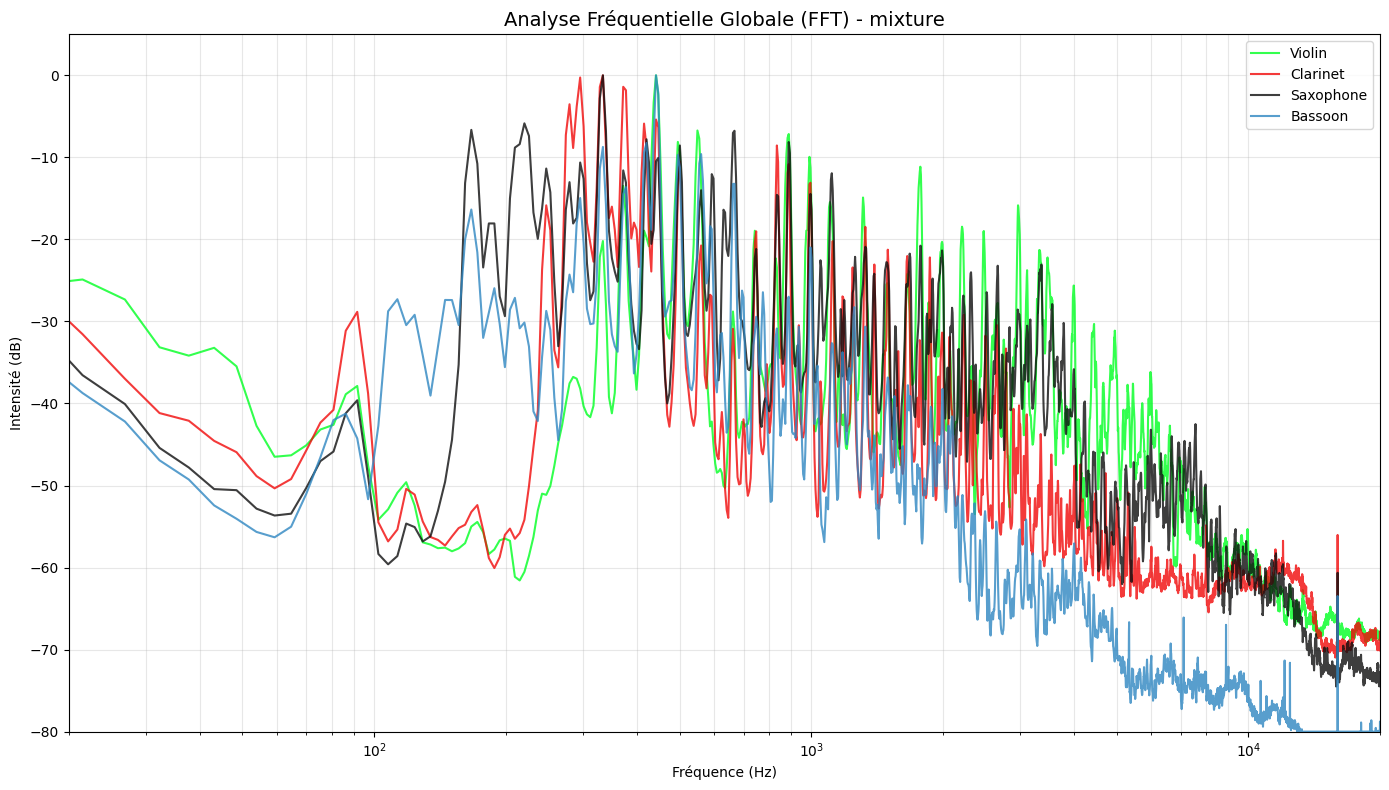

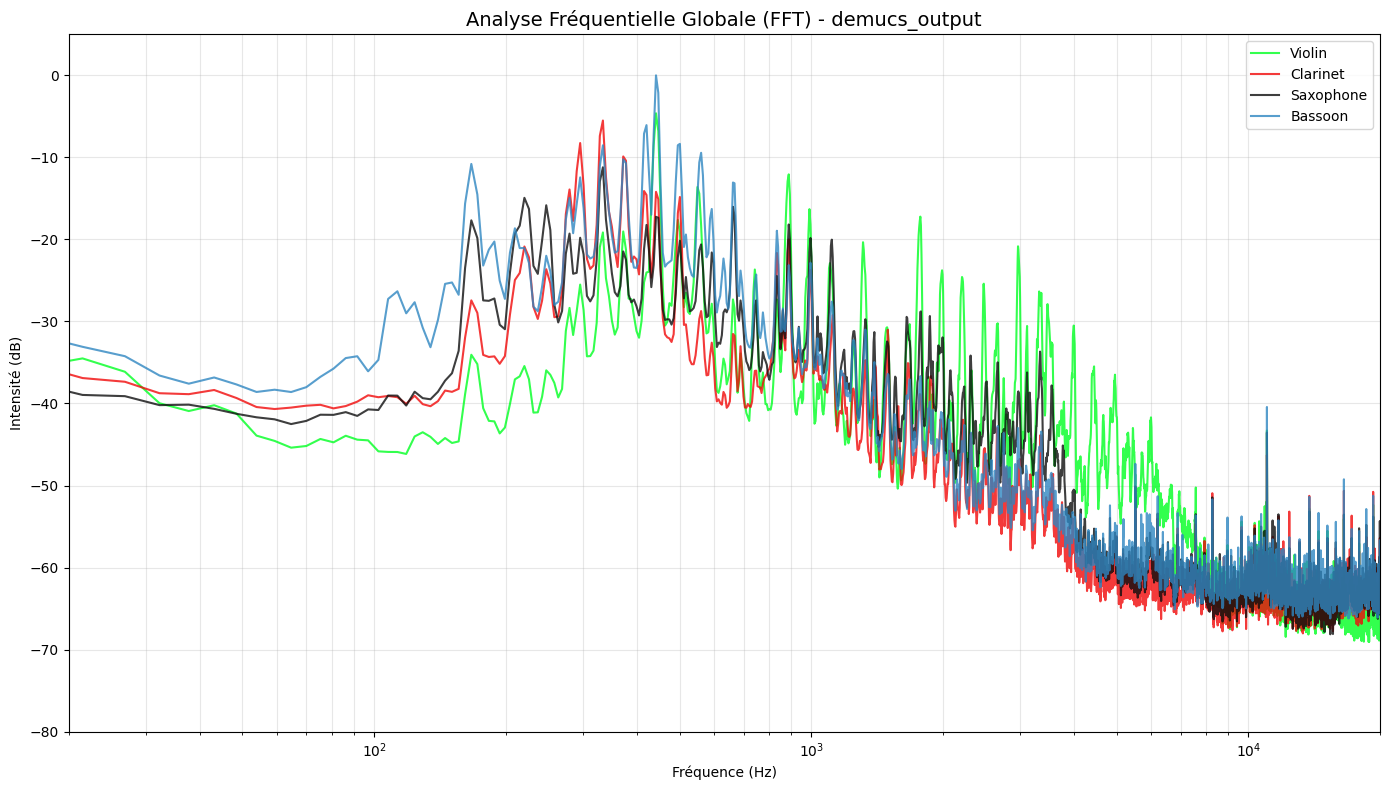

In [8]:
def plot_frequency_spectra(output_dir, song_name):
    instruments = ["violin", "clarinet", "saxophone", "bassoon"]
    colors = ["#00ff22", "#F10909", "#0d0d0e", '#2e86c1']

    plt.figure(figsize=(14, 8))

    for i, inst in enumerate(instruments):
        file_path = Path(output_dir) / f"{inst}.wav"

        if not file_path.exists():
            continue

        # 1. Chargement du signal démixé
        y, sr = librosa.load(file_path, sr=None)

        # 2. Calcul de la FFT (Magnitude sur tout le morceau)
        # On utilise une grande fenêtre (n_fft) pour avoir la précision de ton image
        n_fft = 8192
        stft = np.abs(librosa.stft(y, n_fft=n_fft))

        # On fait la moyenne sur le temps pour avoir l'intensité globale
        mean_spectrum = np.mean(stft, axis=1)

        # Conversion en Décibels (dB)
        db_spectrum = librosa.amplitude_to_db(mean_spectrum, ref=np.max)

        # Fréquences correspondantes
        freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

        # 3. Affichage
        plt.plot(freqs, db_spectrum, label=inst.capitalize(), color=colors[i], alpha=0.8)

    # 4. Paramétrage pour coller à ton image
    plt.xscale('log')  # Échelle logarithmique (essentiel pour la musique)
    plt.title(f"Analyse Fréquentielle Globale (FFT) - {song_name}", fontsize=14)
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Intensité (dB)")
    plt.xlim(20, 20000)  # Spectre audible : 20Hz à 20kHz
    plt.ylim(-80, 5)     # Plage dynamique pour voir les pics et le bruit de fond
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Utilisation
plot_frequency_spectra("/home/ensta/ensta-baron/Projet_IA_2526/Bach10_Clean/test/10-NunBitten", "mixture")
plot_frequency_spectra("/home/ensta/ensta-baron/Projet_IA_2526/src/fine-tuning_Bach/output/augmented", "demucs_output")

In [5]:
def plot_global_spectrum_comparison(ref_path, est_path, instrument_name):
    # 1. Chargement des fichiers
    y_ref, sr = librosa.load(ref_path, sr=None)
    y_est, _ = librosa.load(est_path, sr=None)

    # 2. Calcul de la Magnitude du Spectre (FFT)
    # On utilise une fenêtre assez grande (n_fft) pour avoir une bonne résolution
    n_fft = 4096

    # Calcul de la moyenne du spectre sur tout le signal
    spec_ref = np.abs(librosa.stft(y_ref, n_fft=n_fft))
    spec_ref_avg = np.mean(spec_ref, axis=1)

    spec_est = np.abs(librosa.stft(y_est, n_fft=n_fft))
    spec_est_avg = np.mean(spec_est, axis=1)

    # Passage en Décibels (dB)
    db_ref = librosa.amplitude_to_db(spec_ref_avg, ref=np.max)
    db_est = librosa.amplitude_to_db(spec_est_avg, ref=np.max)

    # Fréquences correspondantes
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # 3. Affichage
    plt.figure(figsize=(12, 6))

    # Courbe Originale vs Estimée
    plt.plot(freqs, db_ref, label="Référence (Original)", color='blue', alpha=0.6)
    plt.plot(freqs, db_est, label=f"Estimation Demucs ({instrument_name})", color='red', linestyle='--')

    # 4. Courbe de DIFFÉRENCE (L'erreur spectrale)
    # On affiche la différence absolue pour voir où l'IA s'éloigne du réel
    diff = np.abs(db_ref - db_est)
    plt.fill_between(freqs, -100, diff - 100, color='gray', alpha=0.2, label="Erreur (Différence)")

    plt.xscale('log') # Échelle logarithmique car l'audition humaine est log
    plt.title(f"Analyse du Spectre de Puissance : {instrument_name.capitalize()}")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Intensité (dB)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.xlim(20, 20000) # De 20Hz à 20kHz
    plt.ylim(-80, 5)    # Plage dynamique standard

    plt.show()

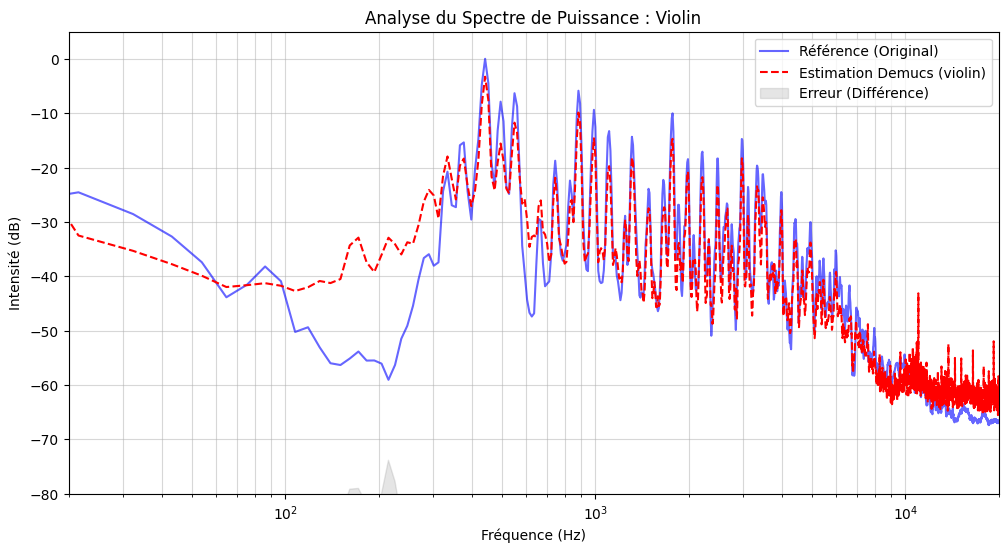

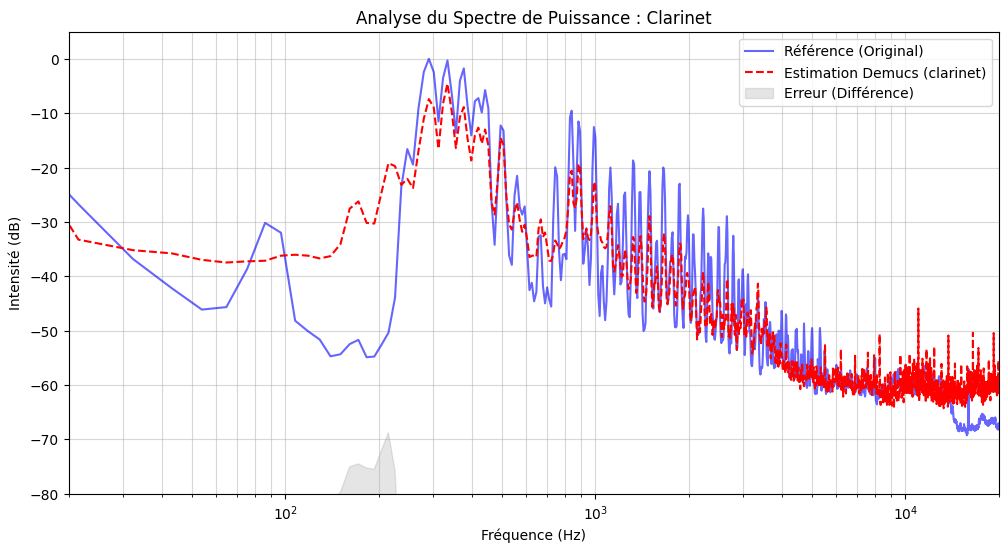

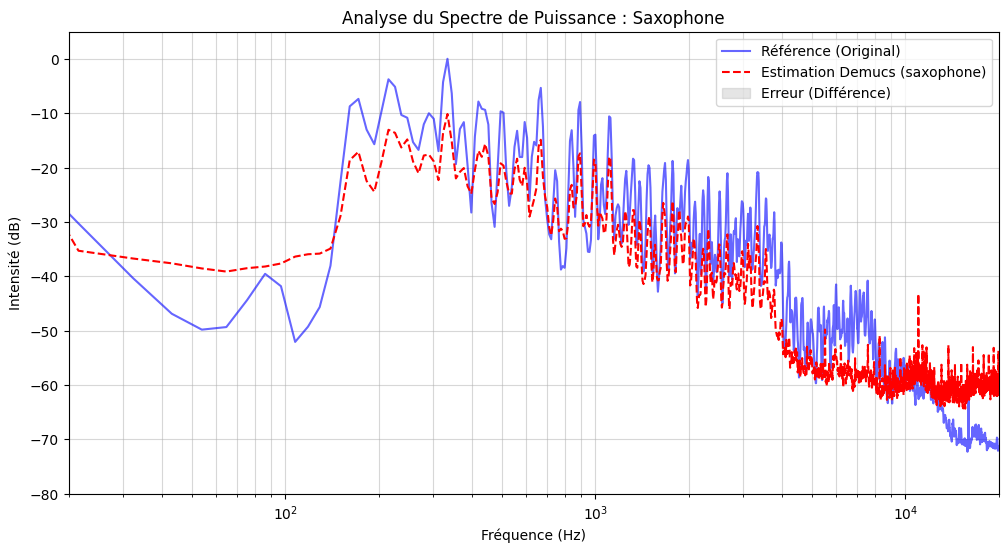

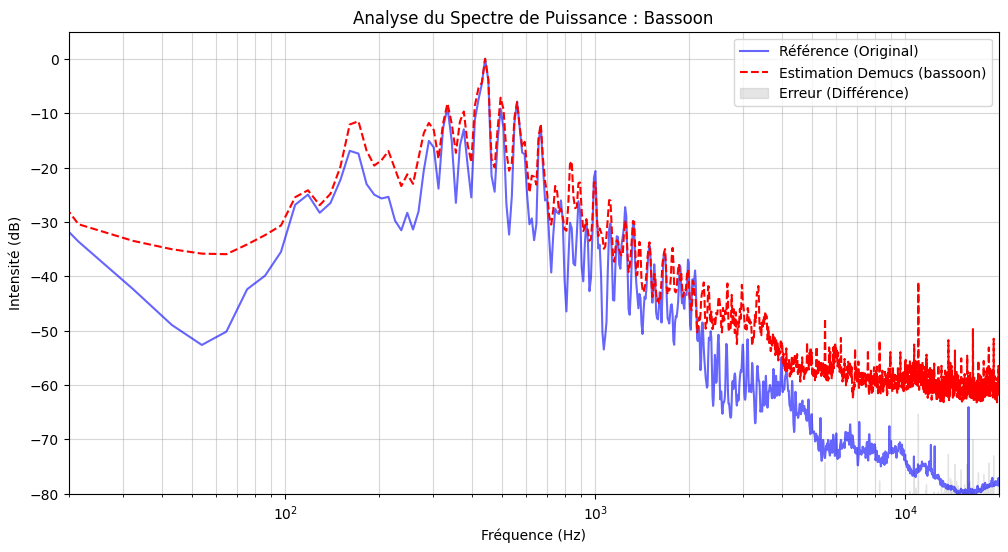

In [6]:
# Exemple d'utilisation :
instruments = ["violin", "clarinet", "saxophone", "bassoon"]
dir_input = "/home/ensta/ensta-baron/Projet_IA_2526/Bach10_Clean/test/10-NunBitten"
dir_output = "/home/ensta/ensta-baron/Projet_IA_2526/src/fine-tuning_Bach/output/augmented"
for i,inst in enumerate(instruments):
  plot_global_spectrum_comparison(f"{dir_input}/{inst}.wav", f"{dir_output}/{inst}.wav", inst)

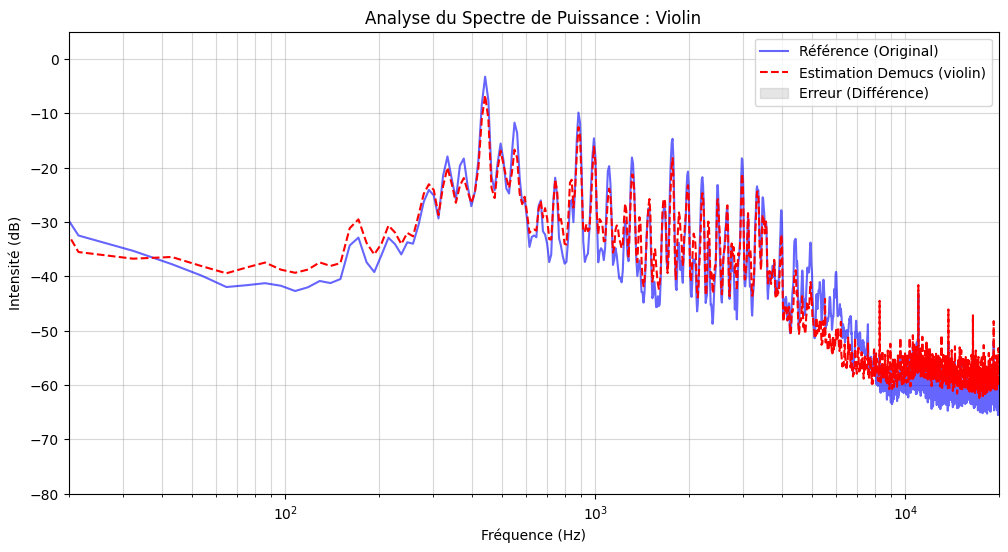

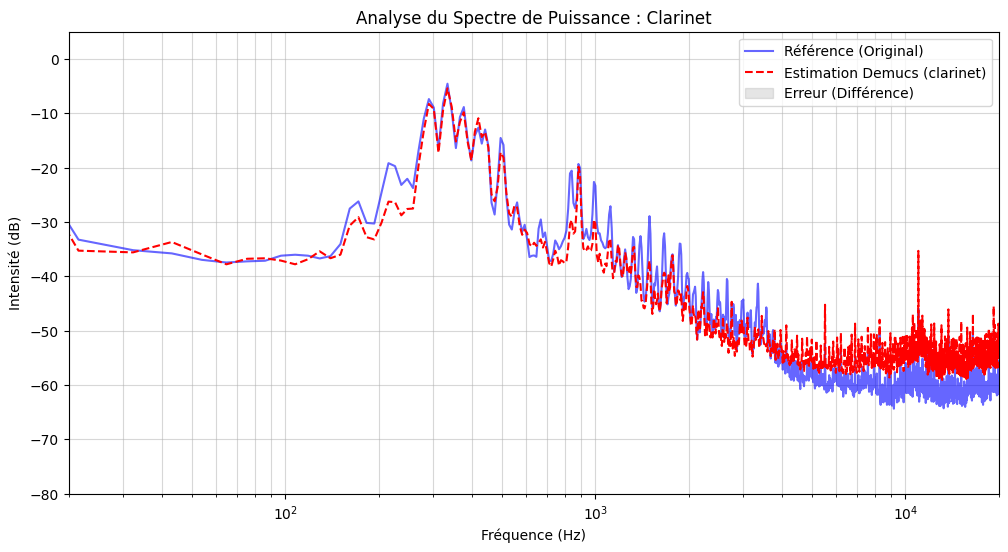

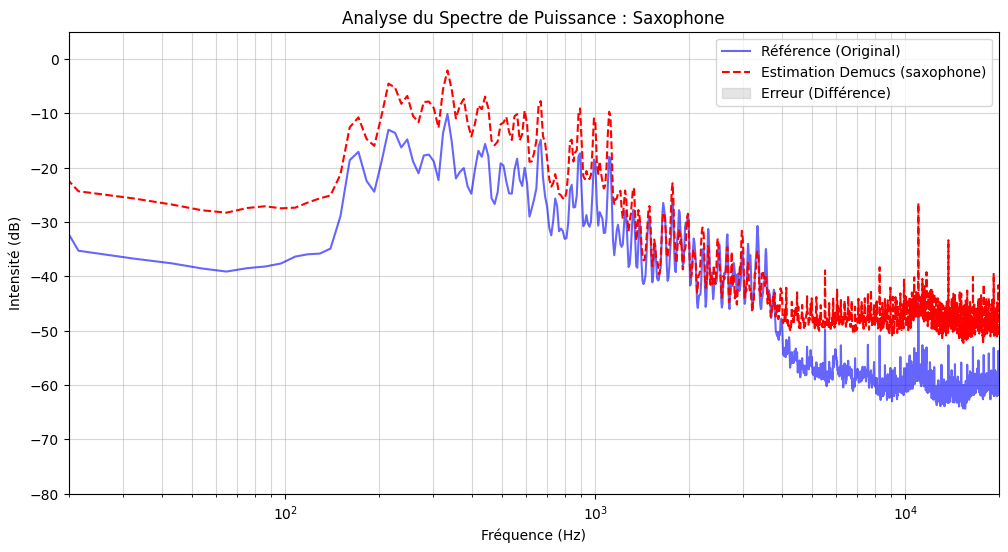

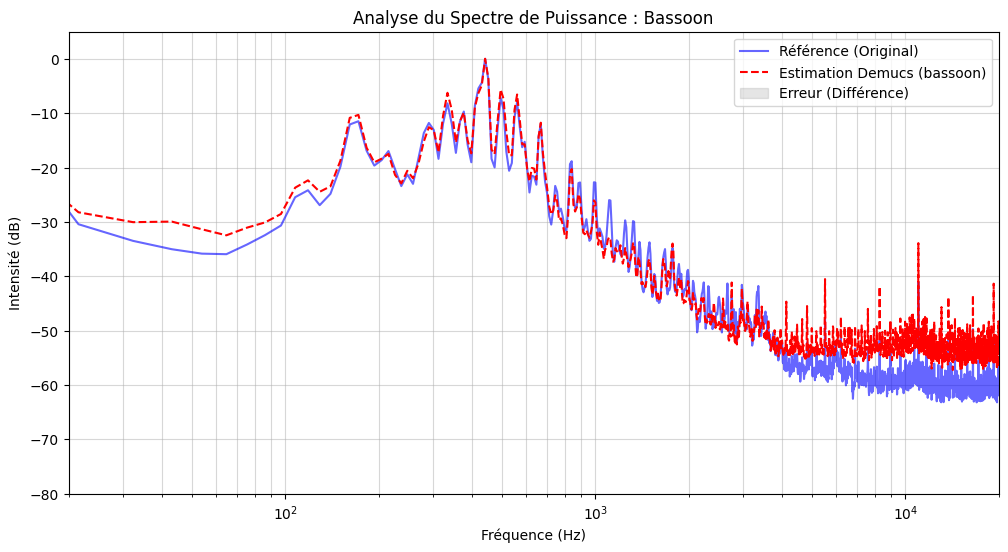

In [ ]:
# Exemple d'utilisation :
instruments = ["violin", "clarinet", "saxophone", "bassoon"]
dir_input = "/home/ensta/ensta-baron/Projet_IA_2526/Bach10_Clean/test/10-NunBitten"
dir_output = "/home/ensta/ensta-baron/Projet_IA_2526/src/fine-tuning_Bach/output/raw"
for i,inst in enumerate(instruments):
  plot_global_spectrum_comparison(f"{dir_input}/{inst}.wav", f"{dir_output}/{inst}.wav", inst)